## Reading in Data

In [19]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
import pickle

movies  = pd.read_csv('data/movies.csv')
ratings = pd.read_csv('data/ratings.csv')

print(f"Ratings: {len(ratings):,}")
print(f"Users:   {ratings['userId'].nunique():,}")
print(f"Movies:  {ratings['movieId'].nunique():,}")

Ratings: 32,000,204
Users:   200,948
Movies:  84,432


## Mean-Centering for SVD

In [20]:
# Mean-center per user so SVD doesn't conflate missing with low ratings
user_means = ratings.groupby('userId')['rating'].mean()
ratings['rating_centered'] = (
    ratings['rating'] - ratings['userId'].map(user_means)
)

## Creating the Sparse Matrix 
* Using CSR: Compressed Sparse Row -- a storage format for sparse matrices that only stores the non-zero values
* Other formats include: CSC (by column), COO (coordinate list), LIL (list of lists)
* CSR is the standard format

In [21]:
# Encode user/movie ids as contiguous integers
user_cat  = ratings['userId'].astype('category')
movie_cat = ratings['movieId'].astype('category')

user_idx  = user_cat.cat.codes.values
movie_idx = movie_cat.cat.codes.values

# Keep these mappings — you'll need them at inference time
user_id_to_idx  = dict(enumerate(user_cat.cat.categories))
movie_id_to_idx = dict(enumerate(movie_cat.cat.categories))
idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}

R = csr_matrix(
    (ratings['rating_centered'].values, (user_idx, movie_idx)),
    shape=(user_cat.nunique(), movie_cat.nunique())
)

print(f"Matrix shape: {R.shape}")
print(f"Sparsity: {1 - R.nnz / (R.shape[0]*R.shape[1]):.4%}")

Matrix shape: (200948, 84432)
Sparsity: 99.8114%


## Training the latent model

In [22]:
# Hold out 20% of ratings per user for evaluation
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

# Rebuild matrix on train only
R_train = csr_matrix(
    (train_data['rating_centered'].values,
     (train_data['userId'].astype('category').cat.codes.values,
      train_data['movieId'].astype('category').cat.codes.values)),
    shape=R.shape
)

### Determining K (# latent factors)

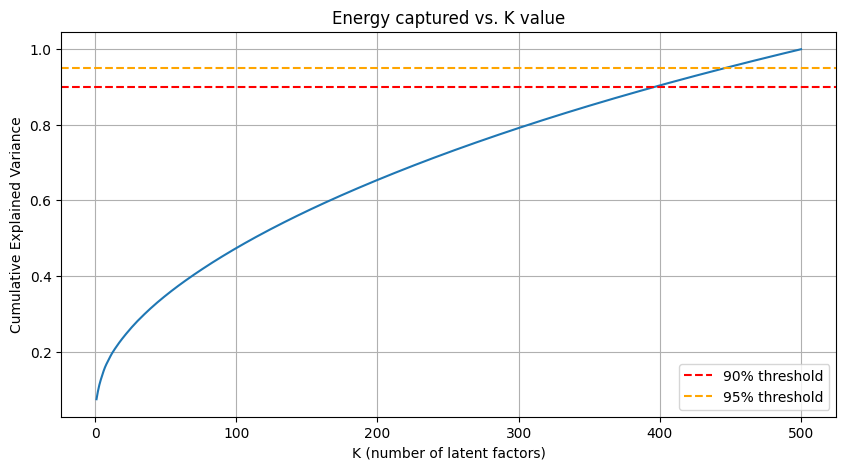

K needed for 80% variance: 307
K needed for 90% variance: 396
K needed for 95% variance: 446


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the SVD with K_max total latent factors
K_max = min(500, min(R_train.shape) - 1)

U_full, sigma_full, Vt_full = svds(R_train, k=K_max)  # get more than you need
sigma_full = sigma_full[::-1]

total_energy = np.sum(sigma_full**2)
cumulative_energy = np.cumsum(sigma_full**2) / total_energy

# Calculate cumulative explained variance as a fraction
sigma_sq = sigma_full ** 2
total_energy = np.sum(sigma_sq)
cumulative_variance = np.cumsum(sigma_sq) / total_energy  # values from 0.0 to 1.0

k_values = np.arange(1, K_max + 1)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, cumulative_variance)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.xlabel("K (number of latent factors)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Energy captured vs. K value")
plt.legend()
plt.grid(True)
plt.show()

# Print the K needed to hit common thresholds
for threshold in [0.80, 0.90, 0.95]:
    k_needed = np.argmax(cumulative_variance >= threshold) + 1  # +1 because 0-indexed
    print(f"K needed for {threshold:.0%} variance: {k_needed}")

## Retraining based on the Selected K value

In [ ]:
k_star = 142
U_k, sigma_k, Vt_k = svds(R_train, k=k_star)

# svds returns singular values in ascending order — flip to descending
U_k    = U_k[:, ::-1]
sigma_k = sigma_k[::-1]
Vt_k    = Vt_k[::-1, :]

# Absorb sigma into both sides (or just item side — your choice)
# Absorbing into items is common: item vectors carry the scale
item_factors = np.diag(sigma_k) @ Vt_k   # shape: (K, n_movies)
user_factors = U_k                       # shape: (n_users, K)

print(f"User factors: {user_factors.shape}")
print(f"Item factors: {item_factors.shape}")

User factors: (610, 142)
Item factors: (142, 9724)


In [16]:
def recommend_for_user(user_idx, user_factors, item_factors,
                       user_means, already_rated, idx_to_movie_id,
                       movie_id_to_title, n=10):
    # Dot product: this user's vector × all item vectors
    scores = user_factors[user_idx] @ item_factors  # shape: (n_movies,)

    # Add back user mean to get predicted absolute rating
    mean = user_means.iloc[user_idx]
    predicted_ratings = scores + mean

    # Zero out already-seen movies
    predicted_ratings[list(already_rated)] = -np.inf

    top_indices = np.argsort(predicted_ratings)[::-1][:n]

    results = []
    for idx in top_indices:
        movie_id = idx_to_movie_id[idx]
        title    = movie_id_to_title.get(movie_id, "Unknown")
        results.append((title, round(predicted_ratings[idx], 3)))

    return results

In [17]:
# Predict on test set and compute RMSE
test_user_idx  = test_data['userId'].astype('category').cat.codes.values
test_movie_idx = test_data['movieId'].astype('category').cat.codes.values

predicted = np.sum(
    user_factors[test_user_idx] * item_factors.T[test_movie_idx],
    axis=1
) + test_data['userId'].map(user_means).values

actual = test_data['rating'].values
rmse   = np.sqrt(np.mean((predicted - actual) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.9782


In [ ]:
artifacts = {
    'user_factors':      user_factors,
    'item_factors':      item_factors,
    'user_means':        user_means,
    'user_id_to_idx':    user_id_to_idx,
    'movie_id_to_idx':   movie_id_to_idx,
    'idx_to_movie_id':   idx_to_movie_id,
    'movie_id_to_title': dict(zip(movies['movieId'], movies['title'])),
    'K':                 k_star,
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved.")

Artifacts saved.
